In [1]:
import anndata
import numpy as np
import gc
import scanpy as sc
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

In [2]:
expr_path = '/data/scRNA/ABCA/AIBS/AWS/expression_matrices/MERFISH-C57BL6J-638850-imputed/20240831/C57BL6J-638850-imputed-log2-wmeta.h5ad'
adata = sc.read_h5ad(expr_path)
adata

AnnData object with n_obs × n_vars = 3938808 × 8460
    obs: 'brain_section_label', 'cluster_alias', 'average_correlation_score', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'x', 'y', 'z', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color'
    var: 'gene_symbol'

# Modules

In [3]:
# Selecting the brain region
select_region = "Isocortex-1"

In [4]:
# Loading Module Eigengenes dataframe
base_path = Path("/data/scRNA/ABCA/AIBS/AWS/expression_matrices/WMB-10Xv3/20230630/outputs")
modules_df = pd.read_csv(base_path / f"WMB-10Xv3-{select_region}-raw-mc-wgcna-modules.csv", index_col="Unnamed: 0")
modules_df.head()

,gene_name,module,color,kME_Isocortex-M1,kME_Isocortex-M2,kME_Isocortex-M3,kME_Isocortex-M4,kME_grey,kME_Isocortex-M5,kME_Isocortex-M6,kME_Isocortex-M7,kME_Isocortex-M8,kME_Isocortex-M9
ENSMUSG00000015090,ENSMUSG00000015090,Isocortex-M1,yellow,0.645442,-0.082131,0.055263,0.123491,-0.087391,0.096088,0.129945,0.244009,0.606363,-0.205105
ENSMUSG00000031425,ENSMUSG00000031425,Isocortex-M1,yellow,0.919267,-0.107151,0.070567,0.095239,-0.112462,0.107643,0.243849,0.051845,0.041710,-0.244151
ENSMUSG00000115529,ENSMUSG00000115529,Isocortex-M1,yellow,0.290416,-0.025055,0.009020,0.027299,-0.029463,0.038628,0.236592,0.012456,0.003026,-0.099603
ENSMUSG00000029819,ENSMUSG00000029819,Isocortex-M2,turquoise,-0.003594,0.542115,0.002021,-0.003075,-0.085746,-0.004960,0.046668,0.012330,0.004241,-0.161405
ENSMUSG00000024610,ENSMUSG00000024610,Isocortex-M3,blue,0.006335,-0.033054,0.153545,0.040280,-0.027896,0.001917,-0.002614,0.018507,0.042056,-0.035275


In [13]:
# Selecting the module of interest
select_module = "Isocortex-M2"

In [14]:
select_genes = modules_df[modules_df["module"] == select_module].index
print("Number of genes in the module: ", select_genes.shape[0])
common_genes = adata.var_names.intersection(select_genes)
adata_subset = adata[:,common_genes].copy()
adata_subset.X = adata_subset.X.astype("float32")
sc.pp.scale(adata_subset, max_value=10)
sc.tl.pca(adata_subset, n_comps=2, svd_solver="arpack")
adata_subset

Number of genes in the module:  285


AnnData object with n_obs × n_vars = 3938808 × 282
    obs: 'brain_section_label', 'cluster_alias', 'average_correlation_score', 'feature_matrix_label', 'donor_label', 'donor_genotype', 'donor_sex', 'x', 'y', 'z', 'neurotransmitter', 'class', 'subclass', 'supertype', 'cluster', 'neurotransmitter_color', 'class_color', 'subclass_color', 'supertype_color', 'cluster_color'
    var: 'gene_symbol', 'mean', 'std'
    uns: 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [15]:
def plot_pca(xx, yy, cc=None, val=None, adata=None, pc_component=None, fig_width=8, fig_height=8, cmap=None, cbar_label=None, title=None):
    fig, ax = plt.subplots()
    fig.set_size_inches(fig_width, fig_height)
    scatter_plot = None  # To hold the scatter plot object
    
    # PCA component coloring
    if pc_component is not None:
        if adata is None:
            raise ValueError("adata must be provided when using pc_component.")
        val = adata.obsm['X_pca'][:, pc_component]
        cmap = cmap or 'viridis'
        scatter_plot = ax.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
        cbar_label = cbar_label or f'ME expression'
        
    # Regular colormap coloring
    elif cmap is not None:
        scatter_plot = ax.scatter(xx, yy, s=0.5, c=val, marker='.', cmap=cmap)
        cbar_label = cbar_label or 'Value'  # Default label
        
    # Categorical color list
    elif cc is not None:
        ax.scatter(xx, yy, s=0.5, color=cc, marker='.')
        
    # Default to black
    else:
        ax.scatter(xx, yy, s=0.5, color='k', marker='.')
    
    # Add color bar if needed
    if scatter_plot is not None:
        cbar = fig.colorbar(scatter_plot, ax=ax, shrink=0.6, aspect=10)
        if cbar_label:
            cbar.set_label(cbar_label, rotation=270, labelpad=15)
    
    ax.set_ylim(11, 0)
    ax.set_xlim(0, 11)
    ax.axis('equal')

    if title is not None:
        ax.set_title(title)
    else:
        ax.set_title(f"Module eigengene for {select_module}")
    ax.set_xticks([])
    ax.set_yticks([])
    return fig, ax

In [16]:
adata_section = adata_subset[adata_subset.obs['brain_section_label'] == 'C57BL6J-638850.38']

In [17]:
module_names = {
    "Isocortex-M1": "Oligodendrocyte Myelination Module",
    "Isocortex-M2": "Neuronal Projection Module",
    "Isocortex-M3": "Immune Response Module",
    "Isocortex-M4": "Vascular Morphogenesis Module",
    "Isocortex-M5": "Developmental Signaling Module",
    "Isocortex-M6": "Neural Development Module",
    "Isocortex-M7": "Structural Morphogenesis Module",
    "Isocortex-M8": "Extracellular Matrix Module",
    "Isocortex-M9": "Axon Guidance Module",
}

(<Figure size 800x500 with 2 Axes>,
 <Axes: title={'center': 'Neuronal Projection Module - Imputed'}>)

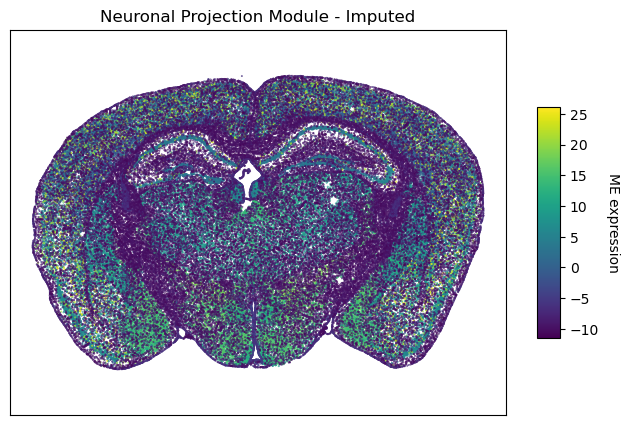

In [18]:
plot_pca(
    adata_section.obs['x'],
    adata_section.obs['y'],
    adata=adata_section,
    pc_component=0,
    cmap='viridis',
    fig_height=5,
    title=f"{module_names[select_module]} - Imputed",)

## Module specificity

In [19]:
'''
Common genes
'''
# Shift the eigengene values to ensure non-negativity
tau_df = adata_subset.obs[["class"]].copy()
tau_df[select_module] = adata_subset.obsm['X_pca'][:,0]
tau_df[select_module] = tau_df[select_module] - tau_df[select_module].min() + 1e-6

# Compute average eigengene per cell class
avg_expression = tau_df.groupby('class')[select_module].mean()

# Normalize by the maximum average expression
max_expr = avg_expression.max()
normalized_expr = avg_expression / max_expr

# Compute tau score
tau = np.sum(1 - normalized_expr) / (len(normalized_expr) - 1)
print(f"Tau specificity score for the module: {tau:.3f}")

Tau specificity score for the module: 0.454


/tmp/ipykernel_48507/2891557603.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_expression = tau_df.groupby('class')[select_module].mean()
